<a href="https://colab.research.google.com/github/NinaNikolova/data_mining_project/blob/main/python_games16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Dimensionality Reduction

In [4]:
from google.colab import drive
drive.mount('/content/drive')
from google.colab import files
uploaded = files.upload()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving video_game_reviews.csv to video_game_reviews (1).csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR, LinearSVR, OneClassSVM
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score

from sklearn.svm import LinearSVC,  LinearSVR, SVC
from sklearn.preprocessing import PolynomialFeatures, LabelEncoder
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
import re
import joblib
import warnings
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
warnings.filterwarnings('ignore')

In [7]:
df = pd.read_csv('/content/video_game_reviews.csv')
df.head()

,Game Title,User Rating,Age Group Targeted,Price,Platform,Requires Special Device,Developer,Publisher,Release Year,Genre,Multiplayer,Game Length (Hours),Graphics Quality,Soundtrack Quality,Story Quality,User Review Text,Game Mode,Min Number of Players
0,Grand Theft Auto V,36.4,All Ages,41.41,PC,No,Game Freak,Innersloth,2015,Adventure,No,55.3,Medium,Average,Poor,"Solid game, but too many bugs.",Offline,1
1,The Sims 4,38.3,Adults,57.56,PC,No,Nintendo,Electronic Arts,2015,Shooter,Yes,34.6,Low,Poor,Poor,"Solid game, but too many bugs.",Offline,3
2,Minecraft,26.8,Teens,44.93,PC,Yes,Bungie,Capcom,2012,Adventure,Yes,13.9,Low,Good,Average,"Great game, but the graphics could be better.",Offline,5
3,Bioshock Infinite,38.4,All Ages,48.29,Mobile,Yes,Game Freak,Nintendo,2015,Sports,No,41.9,Medium,Good,Excellent,"Solid game, but the graphics could be better.",Online,4
4,Half-Life: Alyx,30.1,Adults,55.49,PlayStation,Yes,Game Freak,Epic Games,2022,RPG,Yes,13.2,High,Poor,Good,"Great game, but too many bugs.",Offline,1


In [8]:
numeric_df = df.select_dtypes(include=['number'])  # само числовите колони
target = numeric_df['User Rating']
attributes = numeric_df.drop(columns='User Rating')

In [10]:
# Split into training and test sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(attributes, target, test_size=0.2, random_state=42)

PCA  - най-често използвания метод за намаляване размерността

In [11]:
pca = PCA(n_components=0.95)
pca.fit(X_train)


PCA(n_components=0.95)

In [12]:
pca.components_

array([[-8.98221697e-03,  5.59925853e-04,  9.99959257e-01,
        -7.00399200e-04],
       [ 9.99951620e-01, -3.97714921e-03,  8.98470090e-03,
         4.64764103e-04],
       [ 3.97631567e-03,  9.99925310e-01, -5.16102533e-04,
         1.15454122e-02]])

In [13]:
pca.mean_

array([  39.978978  , 2016.49878333,   32.50448991,    5.11837044])

In [14]:
X_train_transform = pca.transform(X_train)
X_train_transform.shape

(38219, 3)

In [15]:
X_train_transform.std(axis= 0)

array([15.86232218, 11.51475707,  4.02351514])

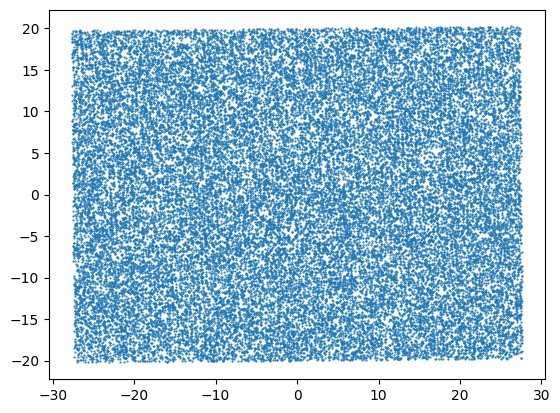

In [11]:
plt.scatter(X_train_transform[:, 0], X_train_transform[:, 1], s = 0.3)

In [16]:
pca.explained_variance_

array([251.61984871, 132.59309968,  16.18909767])

In [17]:
pca.explained_variance_.sum()

np.float64(400.4020460584785)

In [18]:
pca.explained_variance_ratio_ /pca.explained_variance_ratio_.sum()

array([0.62841799, 0.33114991, 0.04043211])

In [19]:
X_test

,Price,Release Year,Game Length (Hours),Min Number of Players
20481,30.35,2012,17.3,4
21278,56.70,2021,25.0,4
37809,44.17,2012,21.8,5
34452,32.23,2016,55.4,3
35793,40.79,2022,39.3,5
...,...,...,...,...
8246,31.07,2013,38.6,3
16656,38.12,2019,47.0,2
44003,34.63,2018,18.5,8
22701,35.71,2014,51.2,4


In [29]:
transformed_data = pca.transform(X_train)

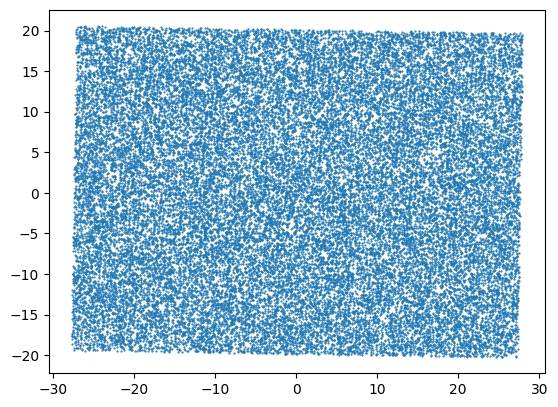

In [30]:
plt.scatter(transformed_data[:, 0], transformed_data[:, 1], s = 0.3)
plt.gca().set_aspect('equal')